In [52]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast, Rescaling


In [19]:
#tf.keras.utils.image_dataset_from_directory??

In [53]:
trainData = tf.keras.utils.image_dataset_from_directory(
    'trainData',
    image_size = (128,128),
    batch_size = 32)

#### Uncomment below after valData is uploaded
valData = tf.keras.utils.image_dataset_from_directory(
    'valData',
    image_size = (128,128),
    batch_size = 32)


Found 6807 files belonging to 3 classes.
Found 3453 files belonging to 3 classes.


In [54]:
trainData = trainData.map(lambda x, y: (x/255, y))
valData = valData.map(lambda x,y: (x/255, y))


In [55]:
# Rerun this to get a new batch
data_iterator = trainData.as_numpy_iterator()
batch = data_iterator.next()
batch[0].shape
##batch[0]-->contains images
##batch[1]-->contains labels

(32, 128, 128, 3)

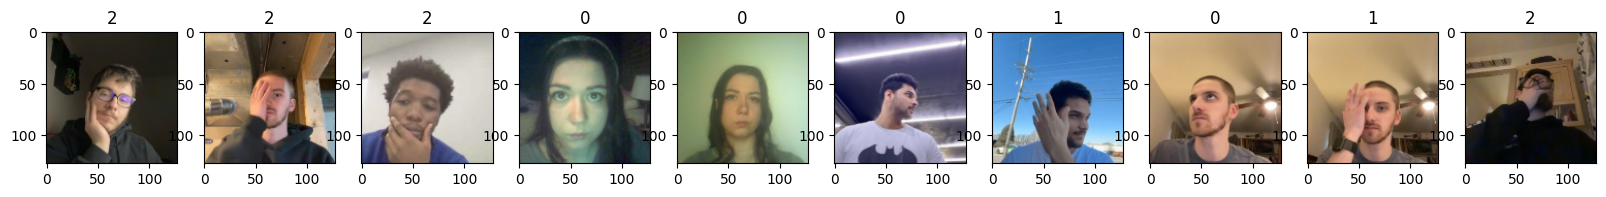

In [56]:
#####      This is for training data     #############
# noHands = 0
# noTouchHands = 1
# touch = 2
fig, ax = plt.subplots(ncols = 10, figsize = (20,20))
for idx, img in enumerate(batch[0][:10]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

In [57]:
# Rerun this to get a new batch
val_data_iterator = valData.as_numpy_iterator()
val_batch = val_data_iterator.next()
val_batch[0].shape
##batch[0]-->contains images
##batch[1]-->contains labels

(32, 128, 128, 3)

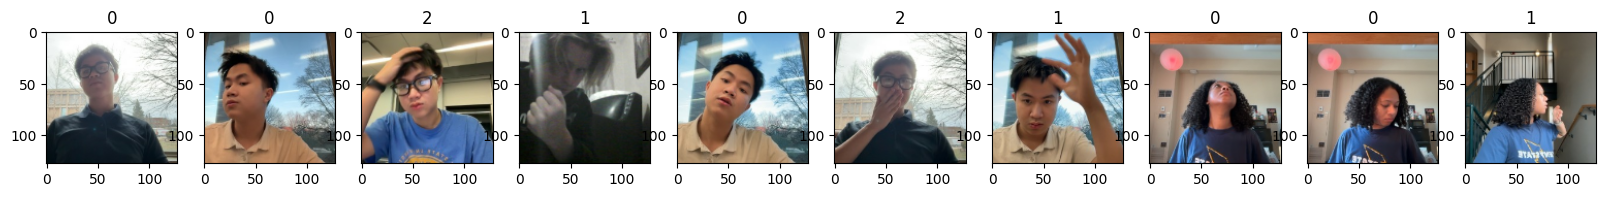

In [58]:
#####      This is for training data     #############
# noHands = 0
# noTouchHands = 1
# touch = 2
fig, ax = plt.subplots(ncols = 10, figsize = (20,20))
for idx, img in enumerate(val_batch[0][:10]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(val_batch[1][idx])

In [59]:
cnn = Sequential()

In [60]:
cnn.add(RandomFlip("horizontal"))
cnn.add(RandomRotation(0.1))
cnn.add(RandomZoom(0.1))
cnn.add(RandomContrast(0.1))
cnn.add(Rescaling(1./255, input_shape=(128,128,3)))

cnn.add(Conv2D(16,(3,3),activation='relu',input_shape=(128,128,3)))
cnn.add(Conv2D(32,(3,3),activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))
cnn.add(Dropout(0.25))
cnn.add(Flatten())
cnn.add(Dense(64,activation='relu'))
cnn.add(Dropout(0.5))
cnn.add(Dense(3,activation='softmax'))

In [61]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
hist = cnn.fit(trainData, epochs = 20, validation_data = valData, verbose = 2)

Epoch 1/20
